# EDA

In [47]:
%load_ext autoreload
%autoreload 2
import medmnist
import torch 
import torch.nn as nn 
import torch.nn.functional as F 
import torch.optim as optim
import torchvision.transforms as transforms

from torch.utils.data import DataLoader
from utils import *
from medmnist import PathMNIST,INFO
from pathlib import Path
from tqdm import tqdm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
ROOT_DIR = "./data"
# Create the directory if it doesn't exist
Path(ROOT_DIR).mkdir(parents=True, exist_ok=True)
SEED = 42
IMG_SIZE = (28, 28)
HIDDEN_SIZE = 256
CHANNELS = 3
NUM_CLASSES = 9
BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 1e-3

In [4]:
dataset = PathMNIST(root=ROOT_DIR, split="train", download=True)

In [33]:
# Load PathMNIST info
data_flag = 'pathmnist'
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

In [34]:
info

{'python_class': 'PathMNIST',
 'description': 'The PathMNIST is based on a prior study for predicting survival from colorectal cancer histology slides, providing a dataset (NCT-CRC-HE-100K) of 100,000 non-overlapping image patches from hematoxylin & eosin stained histological images, and a test dataset (CRC-VAL-HE-7K) of 7,180 image patches from a different clinical center. The dataset is comprised of 9 types of tissues, resulting in a multi-class classification task. We resize the source images of 3×224×224 into 3×28×28, and split NCT-CRC-HE-100K into training and validation set with a ratio of 9:1. The CRC-VAL-HE-7K is treated as the test set.',
 'url': 'https://zenodo.org/records/10519652/files/pathmnist.npz?download=1',
 'MD5': 'a8b06965200029087d5bd730944a56c1',
 'url_64': 'https://zenodo.org/records/10519652/files/pathmnist_64.npz?download=1',
 'MD5_64': '55aa9c1e0525abe5a6b9d8343a507616',
 'url_128': 'https://zenodo.org/records/10519652/files/pathmnist_128.npz?download=1',
 'MD5

In [5]:
print(f"Number of samples: {len(dataset)}")

Number of samples: 89996


In [6]:
for key, value in dataset.info['label'].items():
    print(f"Class {key} : {value}")

Class 0 : adipose
Class 1 : background
Class 2 : debris
Class 3 : lymphocytes
Class 4 : mucus
Class 5 : smooth muscle
Class 6 : normal colon mucosa
Class 7 : cancer-associated stroma
Class 8 : colorectal adenocarcinoma epithelium


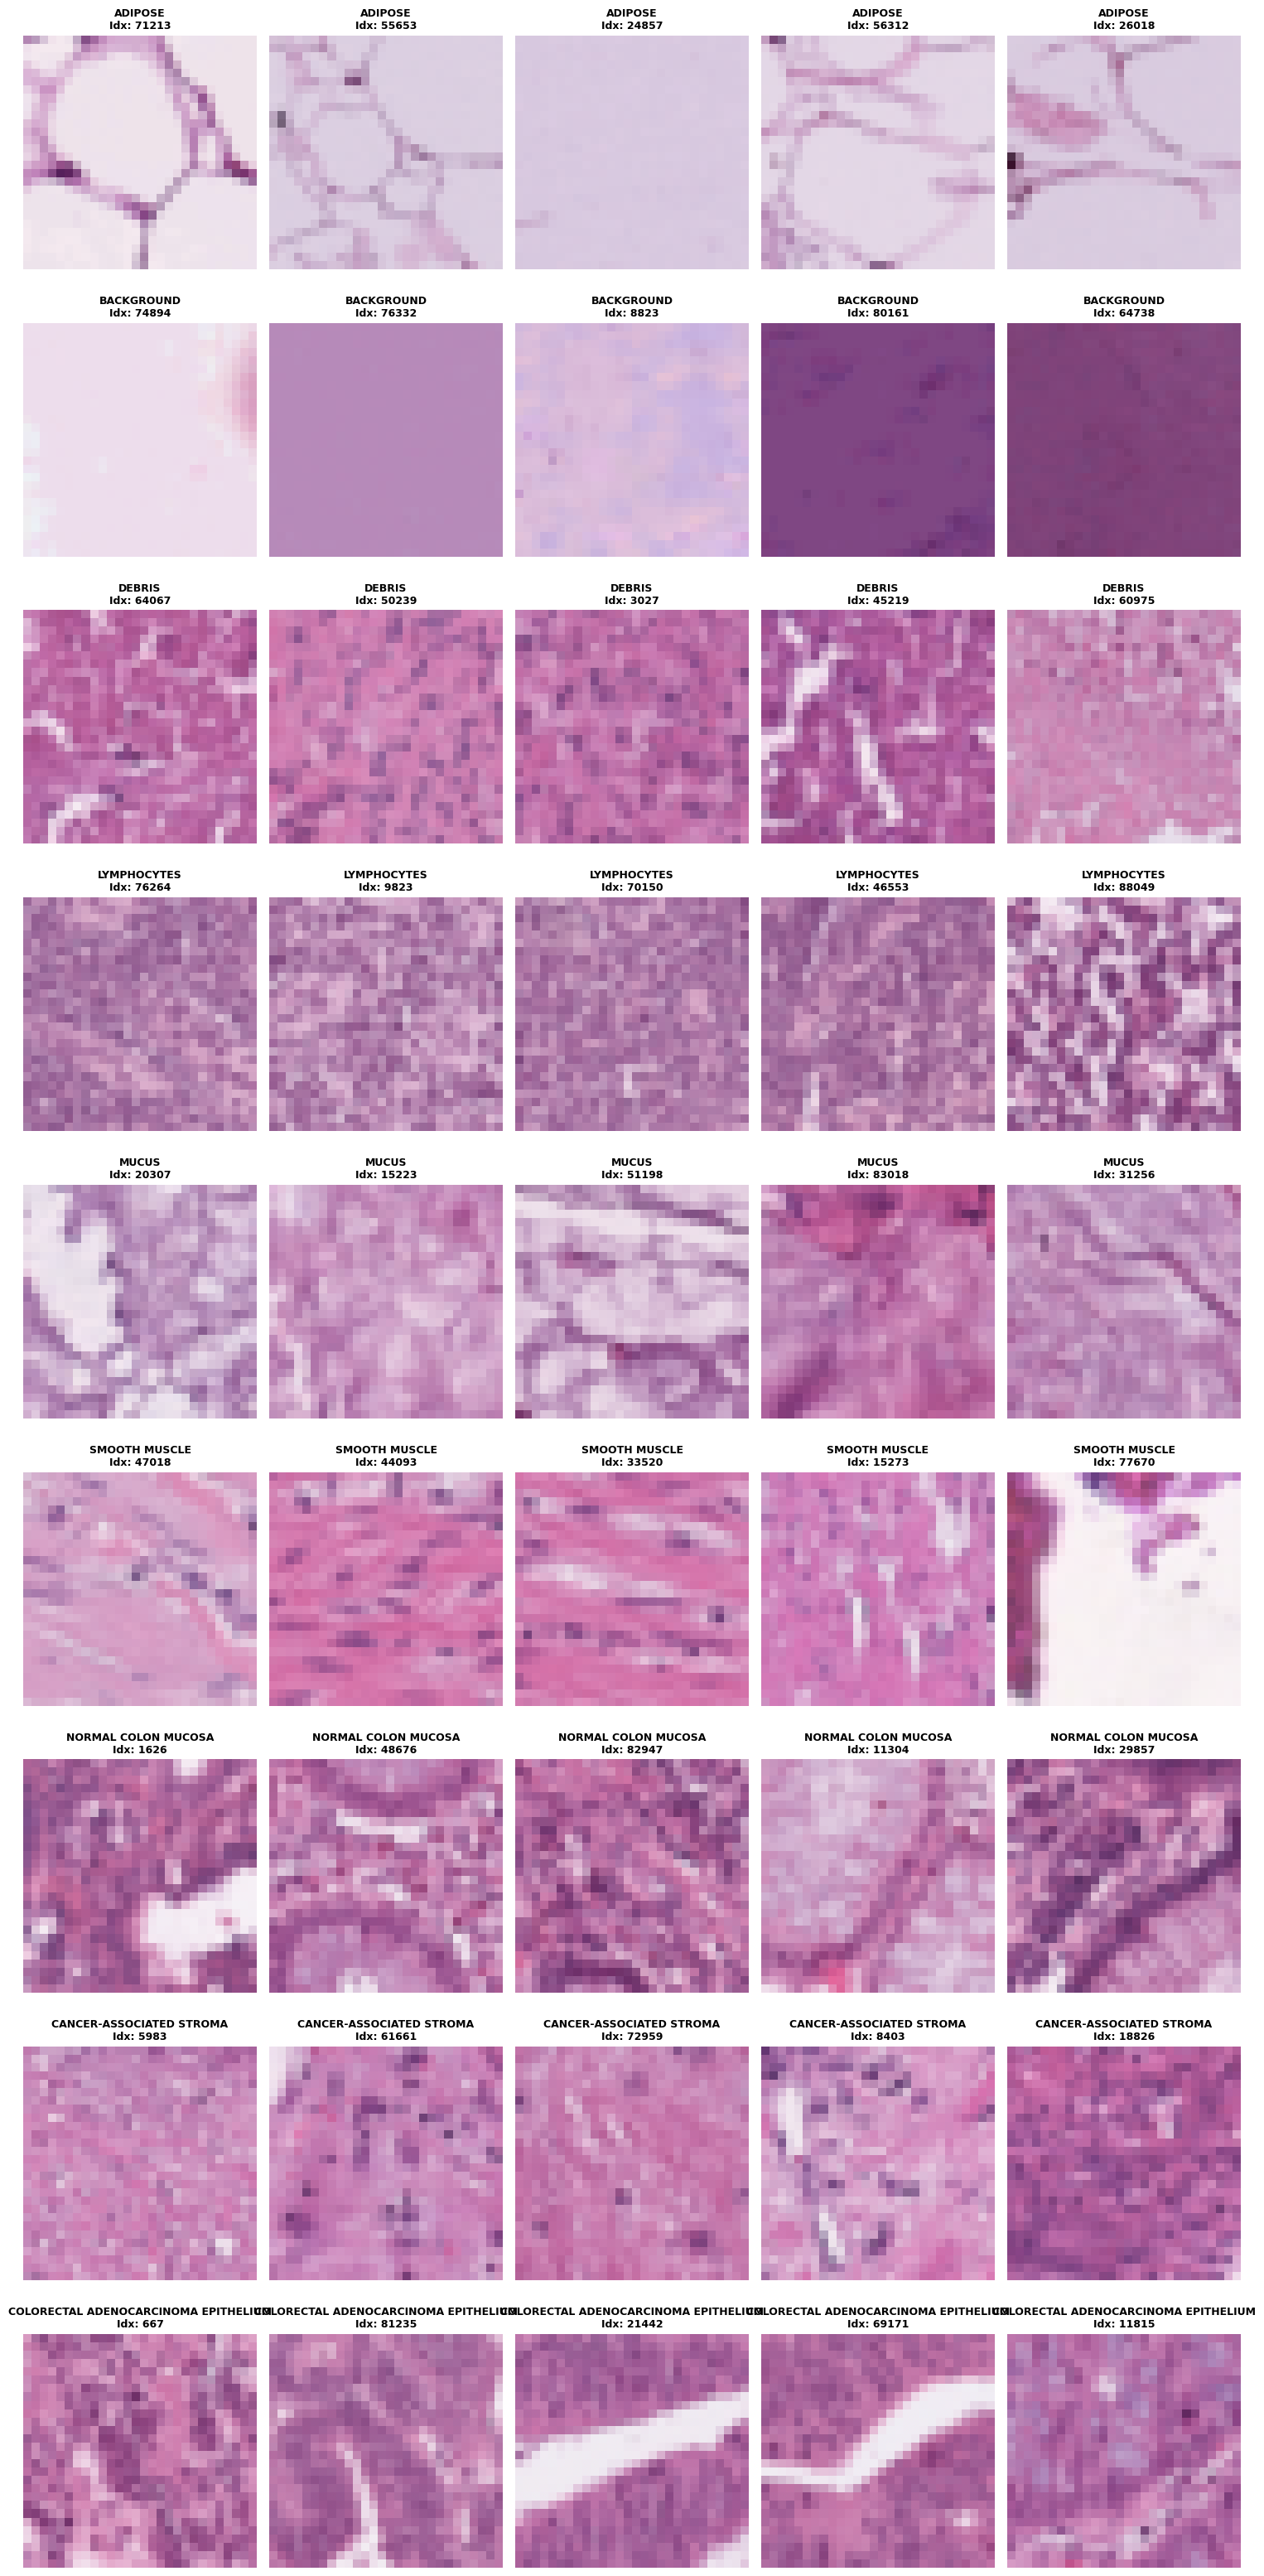

In [7]:
display_medmnist_samples(dataset,"*",5)

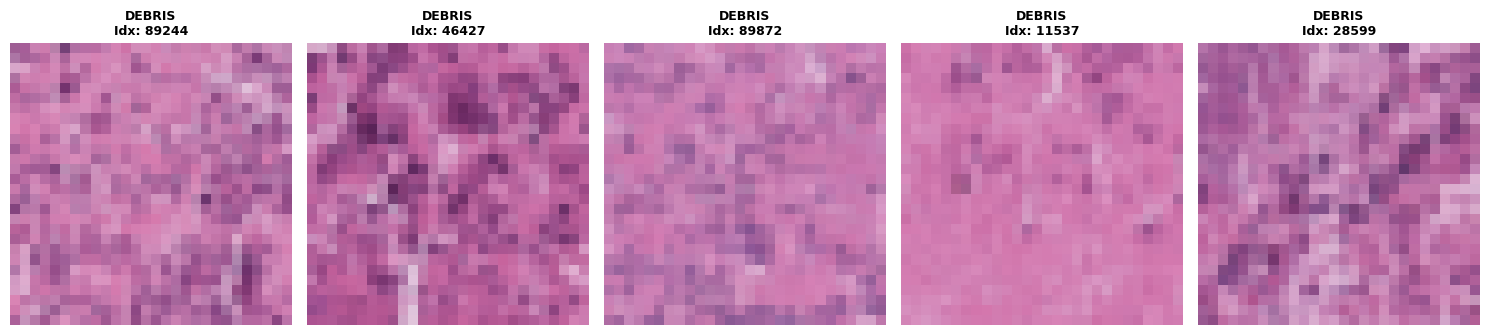

In [8]:
display_medmnist_samples(dataset,"debris",5)

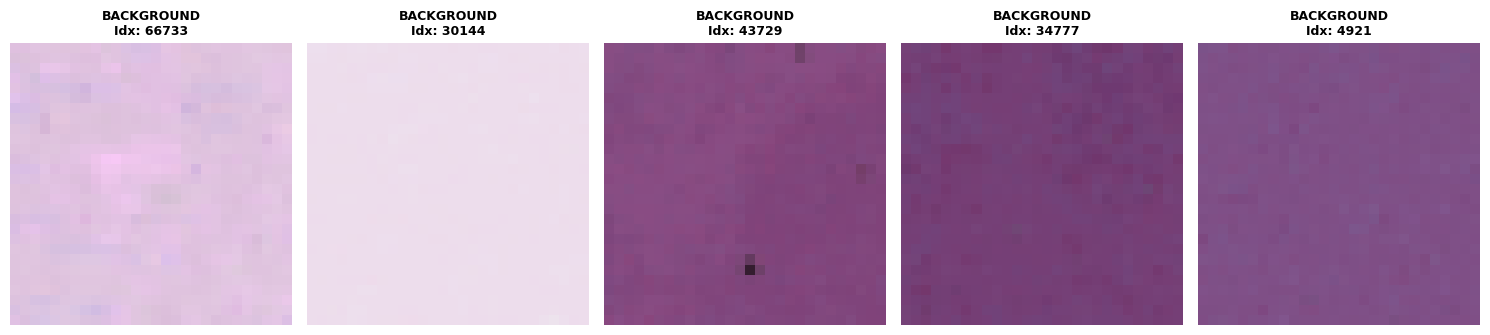

In [9]:
display_medmnist_samples(dataset,"background",5)

In [10]:
print_dataset_structure(dataset)

--- Dataset Structure: PATHMNIST ---
Total samples: 89996
Image shape: (89996, 28, 28, 3)
Labels shape: (89996, 1)
Mode: RGB


In [11]:
plot_class_distribution(dataset)

--- Pixel Stats: Mean=168.25, Std=43.36, Min=0, Max=255 ---


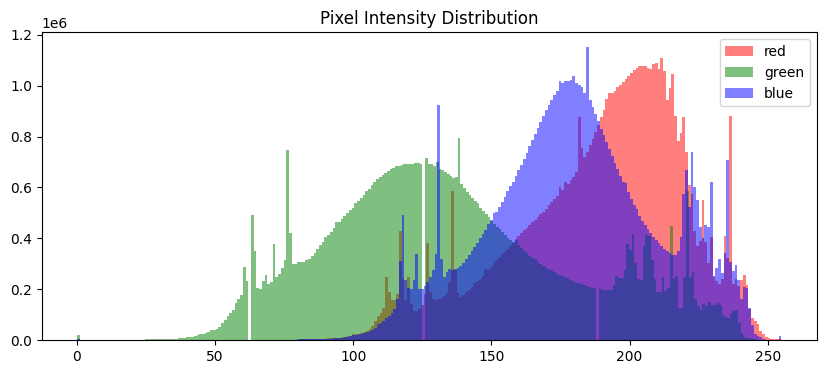

In [12]:
show_pixel_stats(dataset)

--- Stats for Image Index: 15795 (Seed: 42) ---
Mean: 108.66 | Std: 27.71 | Min: 11 | Max: 139
Shape: (28, 28, 3)


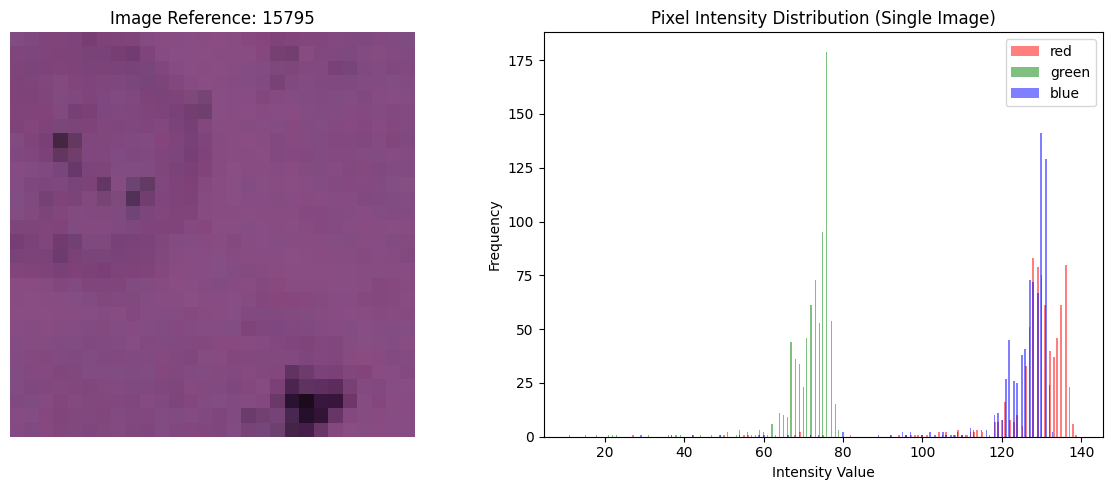

In [15]:
show_random_pixel_stats(dataset)

# Preparing the data

In [37]:
# Simple Preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [39]:
# 2. Load the 3 splits (it only downloads once!)
train_dataset = PathMNIST(root=ROOT_DIR, split="train", transform=transform, download=False)
val_dataset   = PathMNIST(root=ROOT_DIR, split="val",   transform=transform, download=False)
test_dataset  = PathMNIST(root=ROOT_DIR, split="test",  transform=transform, download=False)

# 3. Create your loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# MLP

In [22]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, dropout_prob=0.5):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, num_classes)

        self.dropout = nn.Dropout(dropout_prob)

    def forward(self, x):
        # Flatten the input
        x = x.view(x.size(0), -1)
        # First hidden layer + ReLU + Dropout
        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        # Second hidden layer + ReLU + Dropout
        x = F.relu(self.fc2(x))
        x = self.dropout(x)

        # Output layer
        x = self.fc3(x)
        return x


In [23]:
baseline = MLP(input_size=IMG_SIZE[0] * IMG_SIZE[1] * CHANNELS, hidden_size=HIDDEN_SIZE, num_classes=NUM_CLASSES)

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
baseline = baseline.to(device)
print(baseline)

MLP(
  (fc1): Linear(in_features=2352, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=9, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [26]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=LEARNING_RATE)

Training loop

In [41]:
def train_and_evaluate(model, train_loader, val_loader, criterion, optimizer, epochs, device):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device).squeeze().long()
            
            # Forward + Backward
            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            # Stats
            train_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            train_correct += predicted.eq(labels).sum().item()
            train_total += labels.size(0)
            loop.set_postfix(loss=loss.item())

        # --- VALIDATION PHASE (Required for Q2.1) ---
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device).squeeze().long()
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_correct += predicted.eq(labels).sum().item()
                val_total += labels.size(0)

        # Store metrics
        history['train_loss'].append(train_loss / train_total)
        history['train_acc'].append(100. * train_correct / train_total)
        history['val_loss'].append(val_loss / val_total)
        history['val_acc'].append(100. * val_correct / val_total)
        
        print(f"Summary Epoch {epoch+1}: Val Loss: {history['val_loss'][-1]:.4f} | Val Acc: {history['val_acc'][-1]:.2f}%")
        
    return history

In [42]:
history = train_and_evaluate(baseline, train_loader, val_loader, criterion, optimizer, EPOCHS, device)

Epoch 1/10: 100%|██████████| 704/704 [00:06<00:00, 109.34it/s, loss=1.47]


Summary Epoch 1: Val Loss: 1.3706 | Val Acc: 48.15%


Epoch 2/10: 100%|██████████| 704/704 [00:06<00:00, 115.90it/s, loss=1.34]


Summary Epoch 2: Val Loss: 1.2957 | Val Acc: 51.70%


Epoch 3/10: 100%|██████████| 704/704 [00:06<00:00, 112.18it/s, loss=2.06] 


...

Summary Epoch 8: Val Loss: 1.3010 | Val Acc: 52.74%


Epoch 9/10: 100%|██████████| 704/704 [00:05<00:00, 117.67it/s, loss=1.44]


Summary Epoch 9: Val Loss: 1.3148 | Val Acc: 50.00%


Epoch 10/10: 100%|██████████| 704/704 [00:05<00:00, 119.45it/s, loss=1.13] 


Summary Epoch 10: Val Loss: 1.3141 | Val Acc: 50.53%


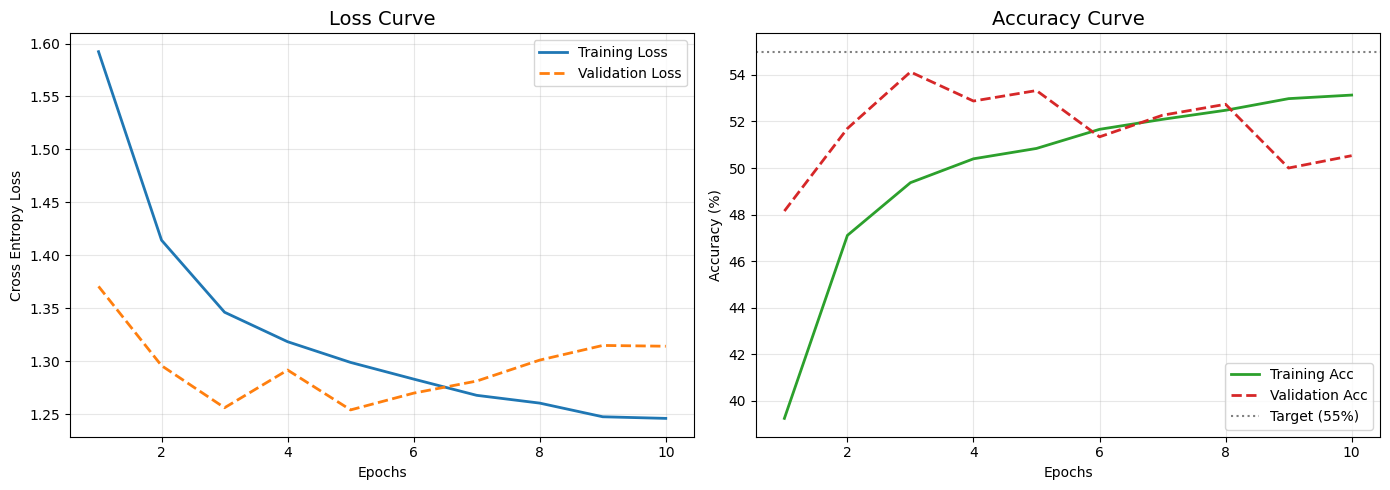

In [48]:
plot_training_history(history)

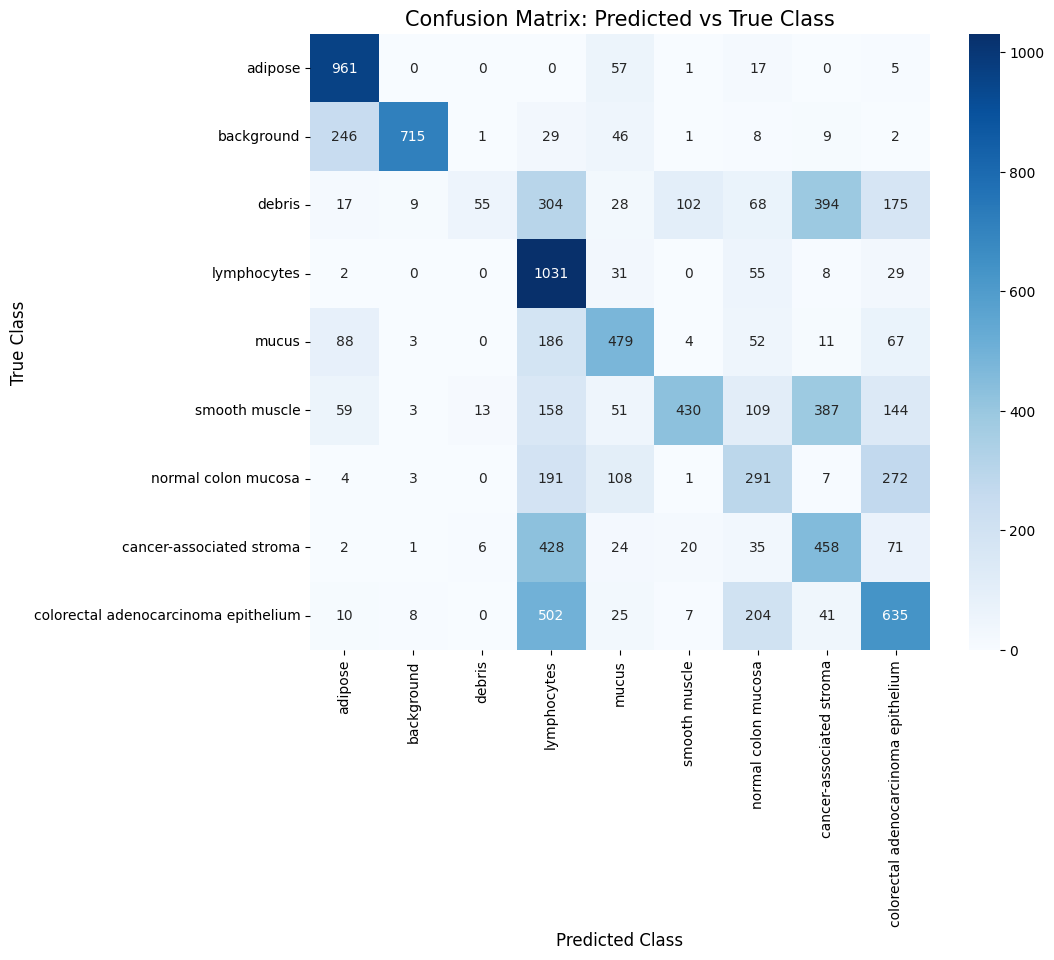

In [52]:
class_names = [train_dataset.info['label'][str(i)] for i in range(9)]
cm = plot_confusion_matrix(baseline, val_loader, device, class_names);

In [53]:
cm_errors = cm.copy()
np.fill_diagonal(cm_errors, 0)

In [54]:
true_idx, pred_idx = np.unravel_index(np.argmax(cm_errors), cm_errors.shape)
max_error_count = cm_errors[true_idx, pred_idx]

print(f"Highest Misclassification: {max_error_count} instances")
print(f"True Class: {class_names[true_idx]} (Index {true_idx})")
print(f"Predicted as: {class_names[pred_idx]} (Index {pred_idx})")

Highest Misclassification: 502 instances
True Class: colorectal adenocarcinoma epithelium (Index 8)
Predicted as: lymphocytes (Index 3)
